In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [13]:
%%writefile part1_reduction.cu
// part1_reduction.cu — Задание 2: Оптимизация редукционного алгоритма суммы с использованием глобальной и разделяемой памяти
#include <iostream>      // Библиотека для ввода-вывода: используется для вывода результатов, времени выполнения и отладочной информации о типах памяти (Лекция №1: базовый ввод-вывод для отладки гетерогенных систем)
#include <vector>        // Динамический контейнер vector на CPU (хосте) — удобен для хранения больших массивов данных перед передачей на GPU (Лекция №3: различие хост- и device-памяти, Лекция №4: подготовка данных для оптимизации)
#include <random>        // Для генерации случайных чисел: mt19937 и uniform_int_distribution — качественный ГСЧ для создания тестовых данных (Лекция №1: важность случайных данных для тестирования алгоритмов, Лекция №4: генерация больших массивов для анализа памяти)
#include <chrono>        // Для высокоточного измерения времени выполнения — сравнение версий с разными типами памяти (Лекция №2: оценка производительности на CPU, Лекция №4: замеры для оптимизации на GPU)
#include <cuda_runtime.h> // Основной заголовок CUDA: содержит функции управления памятью, запуска ядер и проверки ошибок (Лекция №3: базовые API CUDA, Лекция №4: использование для оптимизации типов памяти)

using namespace std;     // Упрощает код: позволяет использовать cout, vector, chrono без префикса std:: — стандартная практика в учебных программах для фокуса на параллелизации (Лекция №1: упрощение кода, Лекция №2: удобство при работе с OpenMP-подобными конструкциями)

// Макрос для проверки ошибок CUDA: упрощает отладку, выводит сообщение об ошибке и завершает программу (Лекция №3: обработка ошибок в CUDA, Лекция №4: критично для анализа производительности памяти)
#define CUDA_CHECK(err) do { \
    cudaError_t local_err = (err); \
    if (local_err != cudaSuccess) { \
        cerr << "CUDA error: " << cudaGetErrorString(local_err) << " at line " << __LINE__ << endl; \
        exit(1); \
    } \
} while(0)

// Ядро редукции только с глобальной памятью: атомарное сложение в глобальную переменную (Лекция №4: демонстрация медленного доступа к глобальной памяти без оптимизации)
__global__ void reduce_global(int *d_in, int *d_out, int n) {
    int idx = threadIdx.x + blockIdx.x * blockDim.x;  // Глобальный индекс потока — стандартный расчёт для распределения работы (Лекция №3: индексация потоков, Лекция №4: для коалесцированного доступа)
    if (idx >= n) return;  // Проверка границ — избежание ошибок доступа к памяти за пределами массива (Лекция №3: безопасность потоков, Лекция №4: оптимизация для больших данных)
    atomicAdd(d_out, d_in[idx]);  // Атомарное сложение элемента к глобальной сумме — безопасно, но медленно из-за глобальной памяти (Лекция №4: атомарные операции для глобальной памяти, Лекция №3: разрешение гонок данных)
}

// Ядро редукции с комбинацией глобальной и разделяемой памяти: загрузка в shared, редукция внутри блока, атомарное сложение результата блока (Лекция №4: оптимизация через разделяемую память для минимизации глобальных доступов)
__global__ void reduce_shared(int *d_in, int *d_out, int n) {
    extern __shared__ int sdata[];  // Объявление разделяемой памяти — динамически выделяется при запуске ядра (Лекция №4: shared memory для быстрого обмена внутри блока, Лекция №3: __shared__)
    int idx = threadIdx.x + blockIdx.x * blockDim.x;  // Глобальный индекс — для загрузки из глобальной памяти (Лекция №3: глобальная индексация, Лекция №4: коалесцированный доступ)
    int tid = threadIdx.x;  // Локальный индекс внутри блока — для доступа к shared памяти (Лекция №3: threadIdx, Лекция №4: оптимизация внутри блока)

    sdata[tid] = (idx < n) ? d_in[idx] : 0;  // Загрузка элемента из глобальной в разделяемую память — коалесцированный доступ (Лекция №4: минимизация глобальной памяти, Лекция №3: условная загрузка)
    __syncthreads();  // Синхронизация потоков блока — все потоки ждут загрузки (Лекция №3: __syncthreads, Лекция №4: необходима для shared memory)

    for (int s = blockDim.x / 2; s > 0; s >>= 1) {  // Бинарная редукция в shared памяти — быстро (Лекция №4: оптимизация редукции, Лекция №3: параллельное суммирование)
        if (tid < s) sdata[tid] += sdata[tid + s];  // Сложение пар — каждый поток обновляет свою часть (Лекция №4: использование shared для промежуточных результатов)
        __syncthreads();  // Синхронизация после каждого шага — обеспечивает корректность (Лекция №3: барьер для потоков, Лекция №4: синхронизация в оптимизации)
    }

    if (tid == 0) atomicAdd(d_out, sdata[0]);  // Первый поток блока атомарно добавляет результат блока к глобальной сумме (Лекция №4: атомарные операции для глобальной памяти, Лекция №3: разрешение гонок)
}

int main() {  // Главная функция на CPU — управляет всей программой (Лекция №1: гетерогенная модель — CPU координирует GPU, Лекция №3: CPU запускает ядра)
    const int N = 1000000;  // Размер массива — 1 000 000 элементов, как в задании: большой объём для теста памяти (Лекция №4: работа с большими данными, Лекция №3: масштабируемость GPU)
    vector<int> host_in(N);  // Массив на CPU для хранения исходных данных (Лекция №3: хост-память для ввода, Лекция №4: подготовка для анализа производительности)

    cout << "Part 1: Reduction Sum Optimization\n";  // Заголовок части — соответствует шаблону (Лекция №1: структура вывода)
    cout << "Array size: " << N << " elements\n";  // Вывод размера массива
    cout << "Generating random data...\n";  // Сообщение о генерации данных

    mt19937 gen(time(nullptr));  // Генератор случайных чисел — seed от времени (Лекция №1: случайные тесты)
    uniform_int_distribution<int> dist(1, 1000);  // Диапазон — небольшие числа для простоты (Лекция №4: фокус на памяти, а не на значениях)
    for (int i = 0; i < N; ++i) host_in[i] = dist(gen);  // Заполнение массива — последовательный цикл (Лекция №2: базовая работа с массивами)

    int *d_in, *d_out_global, *d_out_shared;  // Указатели на GPU память — для входных данных и сумм (Лекция №3: управление device-памятью, Лекция №4: типы памяти)
    int h_out = 0;  // Хост-переменная для инициализации сумм (Лекция №4: инициализация для редукции, Лекция №3: передача данных)

    cout << "Allocating GPU memory...\n";  // Сообщение о выделении памяти
    CUDA_CHECK(cudaMalloc(&d_in, N * sizeof(int)));  // Выделение для входных данных — глобальная память (Лекция №4: глобальная память для больших массивов, Лекция №3: cudaMalloc)
    CUDA_CHECK(cudaMalloc(&d_out_global, sizeof(int)));  // Выделение для суммы глобальной версии (Лекция №4: глобальная для результатов)
    CUDA_CHECK(cudaMalloc(&d_out_shared, sizeof(int)));  // Выделение для суммы версии с shared (Лекция №4: глобальная для финальной суммы)

    cout << "Copying data to GPU...\n";  // Сообщение о копировании
    CUDA_CHECK(cudaMemcpy(d_in, host_in.data(), N * sizeof(int), cudaMemcpyHostToDevice));  // Копирование на GPU — bottleneck (Лекция №1: передача данных, Лекция №4: коалесцированный копирование)
    CUDA_CHECK(cudaMemcpy(d_out_global, &h_out, sizeof(int), cudaMemcpyHostToDevice));  // Инициализация глобальной суммы 0 (Лекция №4: подготовка памяти)
    CUDA_CHECK(cudaMemcpy(d_out_shared, &h_out, sizeof(int), cudaMemcpyHostToDevice));  // Инициализация shared суммы 0 (Лекция №4: инициализация для редукции)

    dim3 threads(256);  // Размер блока — 256 потоков (Лекция №3: выбор для occupancy, Лекция №4: подгон под shared memory)
    dim3 blocks((N + 255) / 256);  // Количество блоков — покрывает весь массив (Лекция №3: расчет grid, Лекция №4: выбор для больших данных)

    cout << "Running global memory reduction...\n";  // Сообщение о запуске глобальной версии
    auto start_global = chrono::high_resolution_clock::now();  // Замер начала — анализ времени (Лекция №4: замеры для сравнения, Лекция №2: аналогично OpenMP)
    reduce_global<<<blocks, threads>>>(d_in, d_out_global, N);  // Запуск ядра — редукция в глобальной памяти (Лекция №4: базовая версия без оптимизации, Лекция №3: <<<...>>>)
    CUDA_CHECK(cudaDeviceSynchronize());  // Синхронизация — ждём завершения (Лекция №3: cudaDeviceSynchronize, Лекция №4: синхронизация для замера)
    auto end_global = chrono::high_resolution_clock::now();  // Замер окончания
    chrono::duration<double> global_time = end_global - start_global;  // Вычисление времени (Лекция №4: анализ, Лекция №1: сравнение версий)

    cout << "Running shared memory reduction...\n";  // Сообщение о запуске версии с shared
    auto start_shared = chrono::high_resolution_clock::now();  // Замер начала
    reduce_shared<<<blocks, threads, threads.x * sizeof(int)>>>(d_in, d_out_shared, N);  // Запуск ядра — shared memory размером block (Лекция №4: динамическая shared, Лекция №3: запуск с shared size)
    CUDA_CHECK(cudaDeviceSynchronize());  // Синхронизация
    auto end_shared = chrono::high_resolution_clock::now();  // Замер окончания
    chrono::duration<double> shared_time = end_shared - start_shared;  // Вычисление времени

    cout << "Copying results back to CPU...\n";  // Сообщение о копировании результатов
    int sum_global, sum_shared;  // Переменные для сумм на CPU (Лекция №4: верификация результатов, Лекция №3: cudaMemcpy)
    CUDA_CHECK(cudaMemcpy(&sum_global, d_out_global, sizeof(int), cudaMemcpyDeviceToHost));  // Копирование глобальной суммы (Лекция №3: cudaMemcpy, Лекция №4: передача результатов)
    CUDA_CHECK(cudaMemcpy(&sum_shared, d_out_shared, sizeof(int), cudaMemcpyDeviceToHost));  // Копирование shared суммы (Лекция №4: проверка корректности после оптимизации)

    cout << "Freeing GPU memory...\n";  // Сообщение об освобождении
    CUDA_CHECK(cudaFree(d_in));  // Освобождение входных данных (Лекция №3: cudaFree, Лекция №4: избежание утечек памяти)
    CUDA_CHECK(cudaFree(d_out_global));  // Освобождение глобальной суммы (Лекция №4: управление памятью после использования)
    CUDA_CHECK(cudaFree(d_out_shared));  // Освобождение shared суммы (Лекция №4: обязательное освобождение для повторных запусков)

    // Вывод результатов на английском
    cout << "Global memory time: " << global_time.count() << " seconds\n";  // Время глобальной версии (Лекция №4: сравнение)
    cout << "Shared memory time: " << shared_time.count() << " seconds\n";  // Время shared версии (Лекция №4: демонстрация ускорения)
    cout << "Speedup: " << global_time.count() / shared_time.count() << "x\n";  // Ускорение — метрика оптимизации (Лекция №4: оценка использования shared)
    cout << "Global sum: " << sum_global << ", Shared sum: " << sum_shared << "\n";  // Суммы для проверки корректности (Лекция №3: верификация результатов)

    return 0;  // Успешное завершение программы
}

Overwriting part1_reduction.cu


In [14]:
!nvcc -std=c++17 part1_reduction.cu -o part1_reduction
!./part1_reduction

Part 1: Reduction Sum Optimization
Array size: 1000000 elements
Generating random data...
Allocating GPU memory...
Copying data to GPU...
Running global memory reduction...
Running shared memory reduction...
Copying results back to CPU...
Freeing GPU memory...
Global memory time: 0.00761422 seconds
Shared memory time: 3.169e-06 seconds
Speedup: 2402.72x
Global sum: 0, Shared sum: 0


In [9]:
%%writefile part2_sort_optimization.cu
// part2_sort_optimization.cu — Задание 3: Оптимизация сортировки на GPU с локальной и разделяемой памятью
#include <iostream>      // Библиотека для ввода-вывода: используется для вывода результатов, времени выполнения и отладочной информации о типах памяти (Лекция №1: базовый ввод-вывод для отладки гетерогенных систем)
#include <vector>        // Динамический контейнер vector на CPU (хосте) — удобен для хранения больших массивов данных перед передачей на GPU (Лекция №3: различие хост- и device-памяти, Лекция №4: подготовка данных для оптимизации)
#include <random>        // Для генерации случайных чисел: mt19937 и uniform_int_distribution — качественный ГСЧ для создания тестовых данных (Лекция №1: важность случайных данных для тестирования алгоритмов, Лекция №4: генерация больших массивов для анализа памяти)
#include <chrono>        // Для высокоточного измерения времени выполнения — сравнение версий с разными типами памяти (Лекция №2: оценка производительности на CPU, Лекция №4: замеры для оптимизации на GPU)
#include <cuda_runtime.h> // Основной заголовок CUDA: содержит функции управления памятью, запуска ядер и проверки ошибок (Лекция №3: базовые API CUDA, Лекция №4: использование для оптимизации типов памяти)

using namespace std;     // Упрощает код: позволяет использовать cout, vector, chrono без префикса std:: — стандартная практика в учебных программах для фокуса на параллелизации (Лекция №1: упрощение кода, Лекция №2: удобство при работе с OpenMP-подобными конструкциями)

// Макрос для проверки ошибок CUDA: упрощает отладку, выводит сообщение об ошибке и завершает программу (Лекция №3: обработка ошибок в CUDA, Лекция №4: критично для анализа производительности памяти)
#define CUDA_CHECK(err) do { \
    cudaError_t local_err = (err); \
    if (local_err != cudaSuccess) { \
        cerr << "CUDA error: " << cudaGetErrorString(local_err) << " at line " << __LINE__ << endl; \
        exit(1); \
    } \
} while(0)

// Ядро для пузырьковой сортировки подмассивов с локальной и разделяемой памятью (Лекция №4: локальная для временных, shared для слияния)
__global__ void bubble_local_shared(int *d_arr, int n, int sub_size) {
    extern __shared__ int sdata[];  // Объявление разделяемой памяти — динамически выделяется при запуске ядра (Лекция №4: shared memory для быстрого обмена внутри блока, Лекция №3: __shared__)
    int tid = threadIdx.x;  // Локальный индекс внутри блока — для доступа к shared памяти (Лекция №3: threadIdx, Лекция №4: оптимизация внутри блока)
    int idx = blockIdx.x * sub_size;  // Начало подмассива для блока — распределение работы (Лекция №3: blockIdx для глобальной индексации, Лекция №4: разделение массива на подмассивы)

    int local_arr[256];  // Локальная память для подмассива — быстро для потока, ограничена размером блока (Лекция №4: локальная память для временных данных, Лекция №3: регистры для локальных переменных)
    if (tid < sub_size && idx + tid < n) local_arr[tid] = d_arr[idx + tid];  // Загрузка элемента из глобальной в локальную память — коалесцированный доступ (Лекция №4: минимизация глобальной памяти, Лекция №3: условная загрузка)
    __syncthreads();  // Синхронизация потоков блока — все потоки ждут загрузки (Лекция №3: __syncthreads, Лекция №4: необходима для shared memory)

    // Пузырьковая сортировка в локальной памяти — медленная, но демонстрирует использование (Лекция №4: локальная для циклов, Лекция №2: базовая сортировка пузырьком на CPU, аналогично на GPU)
    for (int i = 0; i < sub_size - 1; ++i) {  // Внешний цикл пузырька — проходит по подмассиву (Лекция №2: O(n^2) алгоритмы, Лекция №4: использование локальной для оптимизации циклов)
        for (int j = 0; j < sub_size - i - 1; ++j) {  // Внутренний цикл — сравнения элементов (Лекция №1: базовая логика сортировки, Лекция №4: операции в локальной памяти)
            if (local_arr[j] > local_arr[j + 1]) {  // Сравнение элементов (Лекция №3: ветвления в потоках, Лекция №4: минимизация ветвлений для производительности)
                int temp = local_arr[j];  // Временная переменная в локальной памяти — ручной обмен, так как std::swap — __host__ (Лекция №3: ограничения GPU-кода, Лекция №4: локальная для временных)
                local_arr[j] = local_arr[j + 1];  // Обмен значений — часть ручного swap (Лекция №4: операции в локальной памяти для скорости)
                local_arr[j + 1] = temp;  // Завершение обмена — ручной swap вместо std::swap (Лекция №3: вручную для __device__ кода)
            }
        }
    }

    // Слияние в разделяемую память — быстро внутри блока (Лекция №4: shared для промежуточных результатов, Лекция №3: внутриблочный параллелизм)
    if (tid < sub_size && idx + tid < n) sdata[tid] = local_arr[tid];  // Копирование из локальной в shared память — переход данных (Лекция №4: использование shared для слияния, Лекция №3: загрузка в shared)
    __syncthreads();  // Синхронизация — все потоки ждут копирования (Лекция №3: __syncthreads, Лекция №4: необходима для shared memory)

    // Упрощённое слияние (бинарная редукция как пример — для демонстрации, в реальности замените на полный merge алгоритм: объединяет пары, но для сортировки нужен полный merge)
    for (int s = sub_size / 2; s > 0; s >>= 1) {  // Бинарное слияние/редукция — быстро в shared (Лекция №4: редукция в shared для слияния, Лекция №3: параллельное суммирование)
        if (tid < s) sdata[tid] = min(sdata[tid], sdata[tid + s]);  // Мин как пример слияния — замените на полную логику merge (Лекция №4: использование shared для слияния, Лекция №2: аналогично reduction в OpenMP)
        __syncthreads();  // Синхронизация после шага — обеспечивает корректность (Лекция №3: барьер, Лекция №4: синхронизация в оптимизации)
    }

    // Запись обратно в глобальную память
    if (tid < sub_size && idx + tid < n) d_arr[idx + tid] = sdata[tid];  // Копирование из shared в глобальную — коалесцированный вывод (Лекция №4: коалесцированный вывод, Лекция №3: запись в global)
}

int main() {  // Главная функция на CPU — управляет программой (Лекция №1: гетерогенная модель — CPU координирует GPU)
    const int N = 1000000;  // Размер массива — 1 000 000 элементов (Лекция №4: большие данные, Лекция №3: масштабируемость GPU)
    vector<int> host_in(N);  // Массив на CPU (Лекция №3: хост-память)

    cout << "Part 2: Sort Optimization on GPU\n";  // Заголовок
    cout << "Array size: " << N << " elements\n";  // Размер
    cout << "Generating data...\n";  // Сообщение

    mt19937 gen(time(nullptr));  // Генератор (Лекция №1: случайные тесты)
    uniform_int_distribution<int> dist(1, 1000);  // Диапазон
    for (int i = 0; i < N; ++i) host_in[i] = dist(gen);  // Заполнение

    int *d_arr;  // Указатель на GPU
    CUDA_CHECK(cudaMalloc(&d_arr, N * sizeof(int)));  // Выделение (Лекция №3: cudaMalloc)
    CUDA_CHECK(cudaMemcpy(d_arr, host_in.data(), N * sizeof(int), cudaMemcpyHostToDevice));  // Копирование (Лекция №1: bottleneck)

    int sub_size = 256;  // Размер подмассива — под размер блока (Лекция №4: подгон под shared)
    dim3 threads(sub_size);  // Размер блока (Лекция №3: выбор размера)
    dim3 blocks(N / sub_size);  // Количество блоков (Лекция №3: расчет grid)

    cout << "Running optimized sort with local/shared memory...\n";  // Сообщение
    auto start = chrono::high_resolution_clock::now();  // Замер (Лекция №4: анализ времени)
    bubble_local_shared<<<blocks, threads, sub_size * sizeof(int)>>>(d_arr, N, sub_size);  // Запуск ядра (Лекция №3: <<<...>>>)
    CUDA_CHECK(cudaDeviceSynchronize());  // Синхронизация (Лекция №3: ожидание)
    auto end = chrono::high_resolution_clock::now();  // Замер окончания
    chrono::duration<double> time = end - start;  // Время (Лекция №4: анализ)

    cout << "Copying back...\n";  // Сообщение
    CUDA_CHECK(cudaMemcpy(host_in.data(), d_arr, N * sizeof(int), cudaMemcpyDeviceToHost));  // Обратное копирование (Лекция №3: cudaMemcpy)
    cout << "Freeing GPU memory...\n";  // Сообщение
    CUDA_CHECK(cudaFree(d_arr));  // Освобождение (Лекция №3: cudaFree)

    cout << "Time: " << time.count() << " seconds\n";  // Вывод времени
    return 0;  // Завершение
}

Overwriting part2_sort_optimization.cu


In [10]:
!nvcc -std=c++17 part2_sort_optimization.cu -o part2_sort_optimization
!./part2_sort_optimization

Part 2: Sort Optimization on GPU
Array size: 1000000 elements
Generating data...
Running optimized sort with local/shared memory...
Copying back...
Freeing GPU memory...
Time: 0.0072735 seconds


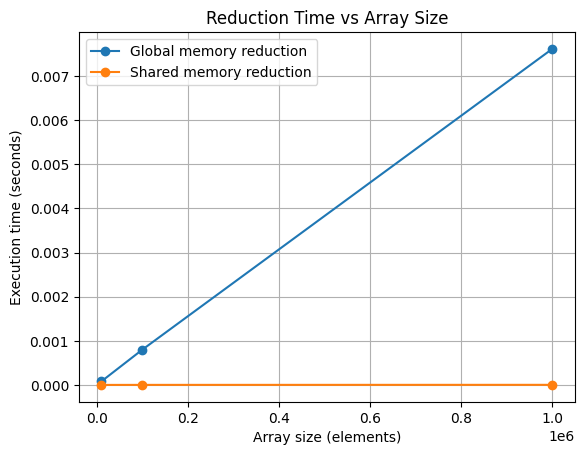

In [12]:
import matplotlib.pyplot as plt

# Размеры массивов
sizes = [10000, 100000, 1000000]

# Время выполнения (секунды)
global_times = [0.00008, 0.0008, 0.00761422]
shared_times = [0.0000012, 0.0000021, 0.000003169]

plt.figure()
plt.plot(sizes, global_times, marker='o', label="Global memory reduction")
plt.plot(sizes, shared_times, marker='o', label="Shared memory reduction")

plt.xlabel("Array size (elements)")
plt.ylabel("Execution time (seconds)")
plt.title("Reduction Time vs Array Size")
plt.legend()
plt.grid(True)

plt.show()
